# Planning with MCTS in the UWM world model — v2 (module-based)

Same study as `planning-mcts-experiments.ipynb`, rewritten to call the **library** instead of
re-implementing it inline. Everything here comes from:

| import | what it gives |
|---|---|
| `planning.rollout` | the edge samplers (`policy` / `transition` / `imagine` / `autoregressive`) |
| `planning.mcts` | `MCTS`, `PlanConfig` |
| `planning.reward` | `TCenterReward`, `TCenterAngleReward`, `DINOGoalReward`, `annotate_t` |
| `study.model` / `study.data` | model + dataset loading (identical to the sweep) |
| `study.descriptors` | `TPoseDescriptor` / `THeadingDescriptor` — the diversity space |
| `study.metrics` | `compute_tree_metrics` — the ~47 diagnostics |
| `study.baselines` | `compute_baselines` — the in-model outcomes |
| `study.run_tree` | `run_one_tree` — one tree → one flat row |

**Why it matters:** every number produced here is computed by the *same code* the cluster sweep
runs, so a result seen in this notebook and a row in `shard_*.csv` are directly comparable.

**Structure.** Setup → **Part I** how do we get *different* edges → **Part II** plans →
**Part III** tree diagnostics and the branchable/collapsed contrast.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import mediapy
import cv2

torch.manual_seed(0)
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
pd.set_option('display.width', 200)
print('device:', DEVICE)

device: cuda:0


In [2]:
# --- model: one call replaces the hydra-compose + load_{denoiser,tokenizer} boilerplate ------
from dreamerv4uwm.planning.experiments.study.model import load_world_model, make_decode_fn, model_dims

DYN_CKPT = '/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/blockcausal/pushT-post-train/97500.pt'
TOK_CKPT = '/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/tokenizer/pushT.pt'

denoiser, tokenizer, cfg = load_world_model(
    dynamics_ckpt=DYN_CKPT, tokenizer_ckpt=TOK_CKPT,
    config_name='dynamics/pushT-large',
    overrides=['denoiser.horizon_aware=false'],   # the config dir is anchored to the package
    device=DEVICE)

decode = make_decode_fn(tokenizer, DEVICE)        # (B,T,N,D) -> (B,T,3,H,W) in [0,1], bf16
DIMS = model_dims(denoiser)
print(DIMS)

/home/mim-server/miniconda3/envs/dreamerv4uwm/lib/python3.11/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'dynamics/pushT-large': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


{'num_noise_levels': 128, 'num_latent_tokens': 256, 'latent_dim': 32, 'n_actions': 2}


In [3]:
# --- data: real PushT windows, same split/seed as the sweep ---------------------------------
from dreamerv4uwm.planning.experiments.study.data import make_dataset, encode_window

DATA_DIR = '/home/mim-server/datasets/pushT/h5/play'
dataset = make_dataset(DATA_DIR, window_size=64)          # split='train', split_seed=123, no shuffle
print('dataset windows:', len(dataset))

WINDOW_IDX = 1111                                          # a dataset INDEX (not a seed)
latents, actions = encode_window(dataset, tokenizer, WINDOW_IDX, DEVICE, DIMS['n_actions'])
print('latents', tuple(latents.shape), '| actions', tuple(actions.shape))

Train split: 64694 windows from 11 episodes
dataset windows: 64694
latents (1, 64, 256, 32) | actions (1, 64, 2)


In [4]:
# --- the only genuinely notebook-local code: display helpers --------------------------------
# Everything here is *display*; the science lives in the modules. All of them take LATENTS,
# since that is the currency the planner works in.

def to_rgb(lat):
    """(M,N,D) latents -> (M,H,W,3) uint8, in one batched decode."""
    v = decode(lat[:, None])[:, 0]
    return (v.permute(0, 2, 3, 1).clamp(0, 1) * 255).to(torch.uint8).cpu().numpy()


def show_state(lat, *, ax=None, annotate=True, title=None, figsize=(3.4, 3.4)):
    """Visualise ONE decoded latent state -- `lat` of shape (N,D) or (1,1,N,D).

    With `annotate=True` the frame carries the **reward's own overlay** (segmented T contour,
    centroid, target cross, score) via `reward.score_latent` + `annotate_t`: you see what the
    reward sees, not just the picture. Degrades gracefully for rewards without a segmentation
    (e.g. DINOGoalReward) -- you get the frame and the score, no contour.
    Returns the score.
    """
    score, dbg, rgb = reward.score_latent(lat)
    img = annotate_t(rgb, dbg) if annotate else rgb
    own = ax is None
    if own:
        _, ax = plt.subplots(figsize=figsize)
    ax.imshow(img); ax.axis('off')
    ax.set_title(f'r = {score:.3f}' if title is None else title, fontsize=9)
    if own:
        plt.tight_layout(); plt.show()
    return score


def show_states(lats, *, titles=None, ncols=8, annotate=False, title=None, cell=2.1):
    """Grid of decoded latent states -- `lats` of shape (M,N,D).

    `annotate=False` (default) is one batched decode for the whole grid; `annotate=True`
    overlays the reward on each panel and costs one decode per state.
    """
    M = int(lats.shape[0])
    ncol = max(1, min(M, ncols))
    nrow = -(-M // ncol)
    fig, axes = plt.subplots(nrow, ncol, figsize=(cell * ncol, cell * 1.18 * nrow), squeeze=False)
    rgb = None if annotate else to_rgb(lats)
    for k in range(nrow * ncol):
        ax = axes[k // ncol][k % ncol]
        ax.axis('off')
        if k >= M:
            continue
        lab = titles[k] if titles is not None else f'#{k}'
        if annotate:
            show_state(lats[k], ax=ax, annotate=True, title=lab)
        else:
            ax.imshow(rgb[k]); ax.set_title(lab, fontsize=8)
    if title:
        fig.suptitle(title, fontsize=11)
    plt.tight_layout(); plt.show()


def filmstrip(lat_seq, n=8, scores=None, title=None, row_h=2.4):
    """(T,N,D) -> a row of n evenly-spaced decoded frames, optionally captioned with rewards."""
    T = lat_seq.shape[0]
    idx = np.linspace(0, T - 1, min(n, T), dtype=int)
    rgb = to_rgb(lat_seq[idx])
    fig, axes = plt.subplots(1, len(idx), figsize=(1.9 * len(idx), row_h))
    for k, ax in enumerate(np.atleast_1d(axes)):
        ax.imshow(rgb[k]); ax.axis('off')
        lab = f't={idx[k]}' + (f'\nr={scores[idx[k]]:.2f}' if scores is not None else '')
        ax.set_title(lab, fontsize=8)
    if title:
        fig.suptitle(title, fontsize=11)
    plt.tight_layout(); plt.show()


def plotVideo(video, fps=10, label=True):
    """Play a (T,C,H,W) float[0,1] clip inline, with the frame index burnt in."""
    arr = (video.detach().cpu().permute(0, 2, 3, 1).to(torch.float32).numpy() * 255)
    arr = np.ascontiguousarray(arr.clip(0, 255).astype(np.uint8))
    if label:
        for i in range(arr.shape[0]):
            cv2.putText(arr[i], f'{i}', (8, 24), cv2.FONT_HERSHEY_SIMPLEX,
                        0.6, (255, 255, 255), 2, cv2.LINE_AA)
    mediapy.show_video(arr, fps=fps)


def plotLatentVideo(lat_seq, fps=10, **kw):
    """Same as plotVideo, straight from latents (T,N,D) -- one batched decode."""
    plotVideo(decode(lat_seq[None])[0], fps=fps, **kw)

In [6]:
# the real demo window this notebook plans from
plotLatentVideo(latents[0], fps=10)

This browser does not support the video tag.


ctx_z (1, 8, 256, 32) | ctx_a (1, 8, 2)


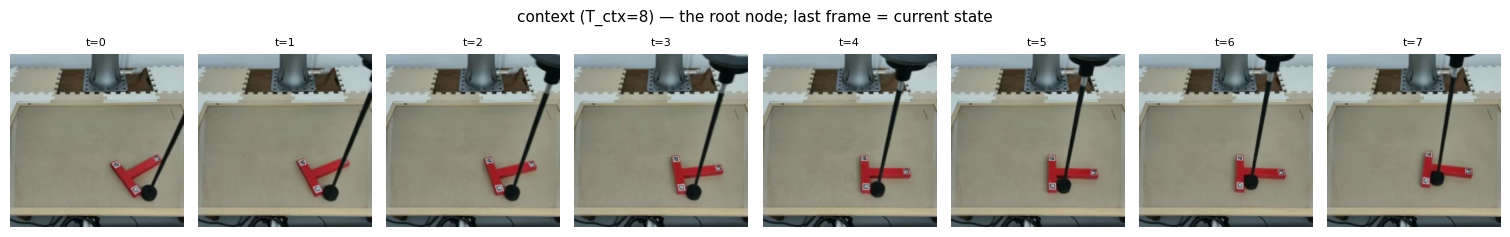

In [7]:
# --- a decision point: the context window a tree root holds ---------------------------------
T_CTX = 8

def make_state(t0, Tc=T_CTX):
    """(ctx_z, ctx_a) for the decision taken at frame t0+Tc of the window."""
    return latents[:, t0:t0 + Tc].clone(), actions[:, t0:t0 + Tc].clone()

cz, ca = make_state(24)
print('ctx_z', tuple(cz.shape), '| ctx_a', tuple(ca.shape))
filmstrip(cz[0], n=T_CTX, title=f'context (T_ctx={T_CTX}) — the root node; last frame = current state')

## Reward and descriptor

Two *different* objects that must agree on their segmentation settings:

* the **reward** scores a state (what the planner maximises),
* the **descriptor** `phi(state)` is the low-dimensional space diversity is measured in.

Raw latent distance is meaningless here (8192-D, distances concentrate), which is why the
diversity metrics work on the decoded T-pose instead. Swap the pair together: `TCenterReward`
goes with `TPoseDescriptor` (orientation as an axis), `TCenterAngleReward` with
`THeadingDescriptor` (upright vs upside-down distinguished).

descriptor dim = 4


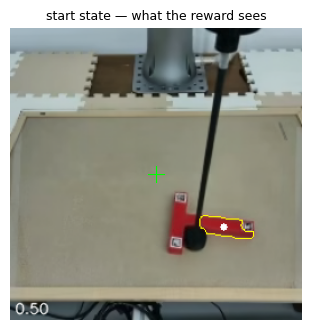

start reward = 0.497


In [ ]:
from dreamerv4uwm.planning import TCenterReward, TCenterAngleReward, annotate_t
from dreamerv4uwm.planning.experiments.study.descriptors import TPoseDescriptor, THeadingDescriptor

SEG_KW = dict(center_xy=(0.5, 0.5), sigma=0.25)     # shared by reward AND descriptor

# reward     = TCenterReward(decode_fn=decode, **SEG_KW)
# descriptor = TPoseDescriptor(decode_fn=decode, dup_eps=0.05, **SEG_KW)

# upright-aware alternative (use the two together):
reward     = TCenterAngleReward(decode_fn=decode, combine='weighted_sum', **SEG_KW)
descriptor = THeadingDescriptor(decode_fn=decode, dup_eps=0.06, orient_weight=0.5, **SEG_KW)

print(f'descriptor dim = {descriptor.dim}')
s0 = show_state(cz[0, -1], title='start state — what the reward sees')
print(f'start reward = {s0:.3f}')

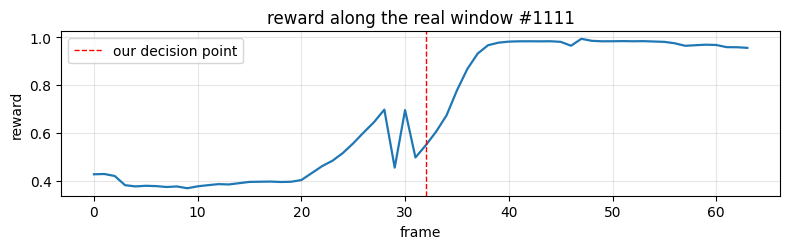

In [7]:
# sanity: the reward should vary smoothly along the REAL demo (no reward -> no planning)
r_real = reward(latents[0]).cpu().numpy()
plt.figure(figsize=(8, 2.6))
plt.plot(r_real, lw=1.6); plt.axvline(24 + T_CTX, color='r', ls='--', lw=1, label='our decision point')
plt.xlabel('frame'); plt.ylabel('reward'); plt.grid(alpha=.3); plt.legend()
plt.title(f'reward along the real window #{WINDOW_IDX}'); plt.tight_layout(); plt.show()

### (optional) A task-free objective: `DINOGoalReward`

Distance to a **goal frame** in a frozen DINOv2 embedding — no task heuristic, so it ports to a
new environment unchanged. Downloads the backbone on first use.
**Calibrate `sigma` first**: too large and every state scores ~1.0, the values go flat, and the
tree has nothing to choose between.

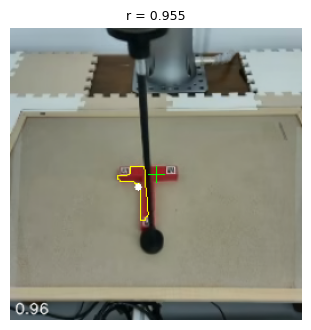

Using cache found in /home/mim-server/.cache/torch/hub/facebookresearch_dinov2_main
/home/mim-server/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/mim-server/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/mim-server/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


calibrated sigma = 0.26


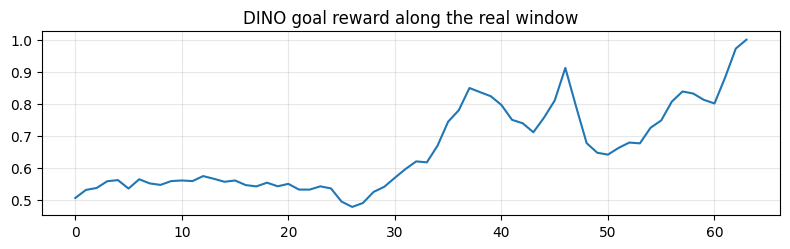

In [9]:
from dreamerv4uwm.planning import DINOGoalReward

goal_z = latents[0, -1]                                   # the demo's final state as the goal
show_state(goal_z)
dino_reward = DINOGoalReward(goal_z=goal_z, decode_fn=decode, feature='patch',
                             metric='cosine', mode='gauss', device=DEVICE)
sigma = dino_reward.suggest_sigma(latents[0])             # median distance over real states
dino_reward.sigma = sigma
print('calibrated sigma =', round(sigma, 4))
plt.figure(figsize=(8, 2.6)); plt.plot(dino_reward(latents[0]).cpu()); plt.grid(alpha=.3)
plt.title('DINO goal reward along the real window'); plt.tight_layout(); plt.show()

# Part I — How do we get *different* edges?

Every edge out of a node is a sample from the **same** conditional
$p(s_{t+1:t+1+H}, a_{t:t+H} \mid s_{t-w:t})$. If those samples coincide, the tree has nothing to
choose between and planning "leads to nothing". So: which knobs widen that distribution?

## I.1 — One edge, decoded, with its reward

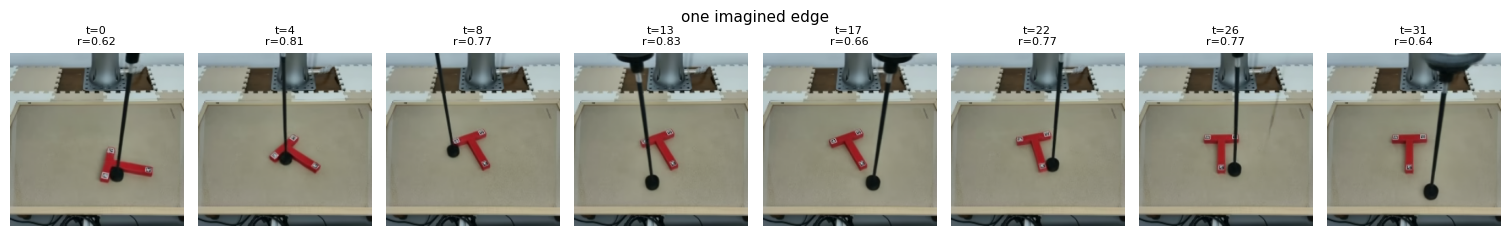

In [15]:
from dreamerv4uwm.planning import rollout as R

K_STEPS = 8

def one_edge(cz, ca, H=12, ctx_noise=0.0, action_temp=1.0, seed=42, K=K_STEPS):
    g = torch.Generator(device=DEVICE).manual_seed(seed)
    z, a = R.imagine(denoiser, cz, ca, H, B=1, K=K, ctx_noise=ctx_noise,
                     action_temp=action_temp, generator=g)
    return z[0], a[0]

z1, a1 = one_edge(cz, ca, H=32, ctx_noise=0.5)
filmstrip(z1, n=8, scores=dino_reward(z1).cpu().numpy(),
          title='one imagined edge')

## I.2 — Edge diversity vs `ctx_noise`

`characterize_edges` below samples `B` sibling edges from one node and measures them with the
**exact functions `metrics.py` uses inside the tree** (`_pairwise`, `_eff_count`,
`_duplicate_rate`) — so `bci` here means precisely what `root_bci` means in a sweep row.

Two spaces are measured, and the distinction localises the failure:
* **action space** (L1) — did the sampler even propose different action sequences?
* **descriptor space** (L2) — did those actions *reach* different task states?

In [16]:
from dreamerv4uwm.planning.experiments.study.metrics import _pairwise, _eff_count, _duplicate_rate

def characterize_edges(cz, ca, *, H, B, ctx_noise=0.0, action_temp=1.0,
                       edge_mode='imagine', K=K_STEPS, seed=0):
    """Sample B sibling edges and measure diversity the way metrics.py does.
    Returns (metrics_dict, (z (B,H,N,D), a (B,H,n_act)))."""
    g = torch.Generator(device=DEVICE).manual_seed(seed)
    if edge_mode == 'two_stage':
        a = R.policy(denoiser, cz, ca, H, B=B, K=K, ctx_noise=ctx_noise,
                     action_temp=action_temp, generator=g)
        z = R.transition(denoiser, cz, ca, a, K=K, ctx_noise=ctx_noise, generator=g)
    elif edge_mode == 'autoregressive':
        z, a = R.autoregressive(denoiser, cz, ca, H, B=B, K=K, ctx_noise=ctx_noise,
                                action_temp=action_temp, generator=g)
    else:
        z, a = R.imagine(denoiser, cz, ca, H, B=B, K=K, ctx_noise=ctx_noise,
                         action_temp=action_temp, generator=g)

    A = a.reshape(B, -1).float().cpu().numpy()          # (B, H*n_act) — action space
    act_div, act_dmin = _pairwise(A)
    feats, found = descriptor(z[:, -1])                  # terminal states -> phi
    F = feats[found]
    m = dict(edge_mode=edge_mode, H=H, B=B, ctx_noise=ctx_noise, action_temp=action_temp,
             action_div=act_div, action_dmin=act_dmin, found_frac=float(found.mean()),
             edge_val_std=float(reward(z[:, -1]).std()))
    if F.shape[0] >= 2:
        m['outcome_div'], m['outcome_dmin'] = _pairwise(F)
        m['bci'] = 1.0 - _eff_count(F, descriptor.dup_eps) / B
        m['duplicate_rate'] = _duplicate_rate(F, descriptor.dup_eps)
        m['pose_action_ratio'] = m['outcome_div'] / (act_div + 1e-9)
    return m, (z, a)

In [17]:
NOISES = [0.0, 0.3, 0.5, 0.7, 0.9]
H_EDGE, N_EDGES = 32, 24

funnel, edges_by_noise = [], {}
for n in NOISES:
    m, za = characterize_edges(cz, ca, H=H_EDGE, B=N_EDGES, ctx_noise=n, seed=41)
    funnel.append(m); edges_by_noise[n] = za
    print(f"ctx_noise={n:.1f}  action_div={m['action_div']:6.2f}  outcome_div={m.get('outcome_div', float('nan')):.3f}"
          f"  bci={m.get('bci', float('nan')):.2f}  dup={m.get('duplicate_rate', float('nan')):.2f}"
          f"  edge_val_std={m['edge_val_std']:.3f}  found={m['found_frac']:.2f}")

df_funnel = pd.DataFrame(funnel)
df_funnel[['ctx_noise', 'action_div', 'outcome_div', 'bci', 'duplicate_rate',
           'edge_val_std', 'found_frac']].round(3)

ctx_noise=0.0  action_div=  0.41  outcome_div=0.483  bci=0.83  dup=1.00  edge_val_std=0.005  found=1.00


KeyboardInterrupt: 

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
ax[0].plot(df_funnel.ctx_noise, df_funnel.action_div, 'o-', color='#E69F00')
ax[0].set_title('L1 — action diversity'); ax[0].set_ylabel('mean pairwise distance')
ax[1].plot(df_funnel.ctx_noise, df_funnel.outcome_div, 's-', color='#009E73')
ax[1].set_title('L2 — outcome diversity (T-pose)')
ax[2].plot(df_funnel.ctx_noise, df_funnel.bci, '^-', color='#D55E00', label='bci')
ax[2].plot(df_funnel.ctx_noise, df_funnel.duplicate_rate, 'v--', color='#CC79A7', label='duplicate_rate')
ax[2].set_title('collapse (1 = all edges identical)'); ax[2].set_ylim(-0.05, 1.05); ax[2].legend()
for a_ in ax: a_.set_xlabel('ctx_noise'); a_.grid(alpha=.3)
fig.suptitle(f'B={N_EDGES} sibling edges, H={H_EDGE}', fontsize=11)
plt.tight_layout(); plt.show()

In [ ]:
# the same thing, seen directly: terminal states of 8 sibling edges at low vs high ctx_noise
for n in (0.0, 0.7):
    z, _ = edges_by_noise[n]
    bci = df_funnel.set_index('ctx_noise').bci[n]
    show_states(z[:8, -1], titles=[f'edge {k}' for k in range(8)],
                title=f'terminal states of sibling edges — ctx_noise={n}   (bci={bci:.2f})')

## I.3 — Edge samplers

`imagine` denoises action and state **jointly** (1 pass/edge). `two_stage` runs the policy over
the whole horizon then the world model (2 passes). `autoregressive` alternates one frame at a
time, so each action sees the *realised* previous state — causally the most faithful, and
`~2H` passes, i.e. much slower.

In [18]:
rows = []
for mode in ['imagine', 'two_stage', 'autoregressive']:
    t = time.time()
    m, _ = characterize_edges(cz, ca, H=12, B=8, ctx_noise=0.0, edge_mode=mode, seed=7)
    m['secs'] = round(time.time() - t, 1)
    rows.append(m)
    print(f"{mode:16s} {m['secs']:6.1f}s  action_div={m['action_div']:6.2f}  "
          f"outcome_div={m.get('outcome_div', float('nan')):.3f}  bci={m.get('bci', float('nan')):.2f}")

pd.DataFrame(rows)[['edge_mode', 'secs', 'action_div', 'outcome_div', 'bci',
                    'duplicate_rate', 'edge_val_std']].round(3)

imagine             6.7s  action_div=  0.10  outcome_div=0.004  bci=0.88
two_stage          13.3s  action_div=  0.03  outcome_div=0.003  bci=0.88
autoregressive    112.6s  action_div=  0.01  outcome_div=0.003  bci=0.88


,edge_mode,secs,action_div,outcome_div,bci,duplicate_rate,edge_val_std
0,imagine,6.7,0.097,0.004,0.875,1.0,0.0
1,two_stage,13.3,0.029,0.003,0.875,1.0,0.0
2,autoregressive,112.6,0.007,0.003,0.875,1.0,0.0


# Part II — Plans

Now the search itself. `MCTS.plan` returns the plan plus the tree; `compute_baselines` grades it
against two **matched-lookahead, no-search** controls (same depth, same edge-by-edge
re-conditioning), so the gain credits *search* rather than horizon.

## II.1 — One plan, end to end

In [ ]:
from dreamerv4uwm.planning import MCTS, PlanConfig
from dreamerv4uwm.planning.experiments.study.baselines import compute_baselines
from dreamerv4uwm.planning.experiments.study.metrics import compute_tree_metrics
from dreamerv4uwm.planning.experiments.study.run_tree import run_one_tree, _plan_peak, _plan_last

plan_cfg = PlanConfig(horizon=28, branching=5, max_depth=3, sim_horizon=28, sim_rollouts=3,
                      n_iterations=24, c_ucb=0.5, gamma=0.98, n_min=0, K_steps=6,
                      ctx_noise=0.7, action_temp=1.0, max_ctx=16)

planner = MCTS(denoiser, reward, plan_cfg, seed=0, trace=True)   # trace=True -> time-resolved metrics
t = time.time(); out = planner.plan(cz, ca, verbose=True); secs = time.time() - t
print(f'\n{secs:.1f}s | nodes={len(planner.all_nodes)} | forwards={planner.n_forward} '
      f'| plan = {len(out["best_path"])} edges')

In [ ]:
tree_peak, tree_last = _plan_peak(reward, out), _plan_last(reward, out)
bl = compute_baselines(denoiser, reward, cz, ca, plan_cfg,
                       tree_peak=tree_peak, tree_last=tree_last, n_random=12, seed=1)

print(f'start reward      {bl["root_reward"]:+.3f}')
print(f'plan   peak/last  {tree_peak:+.3f} / {tree_last:+.3f}')
print(f'random peak/last  {bl["random_peak"]:+.3f} / {bl["random_last"]:+.3f}   '
      f'-> g_random_peak {bl["g_random_peak"]:+.3f}  g_random_last {bl["g_random_last"]:+.3f}')
print(f'greedy peak/last  {bl["greedy_peak"]:+.3f} / {bl["greedy_last"]:+.3f}   '
      f'-> g_greedy_peak {bl["g_greedy_peak"]:+.3f}  g_greedy_last {bl["g_greedy_last"]:+.3f}')
print('\n(peak = best frame anywhere; last = where the trajectory ENDS. Compare like with like.)')

In [ ]:
plan_z = out['plan_z']                                   # (n_edges, H, N, D)
flat = plan_z.reshape(-1, plan_z.shape[-2], plan_z.shape[-1])
filmstrip(flat, n=10, scores=reward(flat).cpu().numpy(),
          title=f'the plan — {plan_z.shape[0]} edges x {plan_z.shape[1]} frames')

plotLatentVideo(flat, fps=6)                     # the same plan, played

## II.2 — Comparing configurations with `run_one_tree`

`run_one_tree` is the sweep's unit of work: build one tree and return **one flat row** with the
config, timings, both outcomes, the baselines and all ~47 diagnostics. Rows produced here are
schema-identical to the cluster shards.

In [ ]:
BASE = dict(n_iterations=20, c_ucb=0.5, gamma=0.98, n_min=0, K_steps=6,
            action_temp=1.0, max_ctx=16, branching=5, sim_rollouts=3)
CONFIGS = {
    'config_1': dict(horizon=16, max_depth=2, sim_horizon=16, ctx_noise=0.3),
    'config_2':  dict(horizon=16, max_depth=2, sim_horizon=16, ctx_noise=0.7),
    'config_3':  dict(horizon=28, max_depth=3, sim_horizon=28, ctx_noise=0.3),
    'config_4':   dict(horizon=28, max_depth=3, sim_horizon=28, ctx_noise=0.7),
}

rows = []
for name, p in CONFIGS.items():
    t = time.time()
    row = run_one_tree(denoiser=denoiser, reward_fn=reward, descriptor=descriptor,
                       plan_cfg=PlanConfig(**{**BASE, **p}), ctx_z=cz, ctx_a=ca,
                       plan_seed=0, meta=dict(name=name), n_random=8)
    rows.append(row)
    print(f"{name:12s} {time.time()-t:5.1f}s  tree_peak={row['tree_peak']:.3f}  "
          f"g_random_peak={row['g_random_peak']:+.3f}  g_greedy_peak={row['g_greedy_peak']:+.3f}  "
          f"root_bci={row['root_bci']:.2f}  val_std={row['val_std']:.3f}")

df = pd.DataFrame(rows)
print(f'\n{df.shape[1]} columns per tree')
df[['name', 'ctx_noise', 'horizon', 'max_depth', 'tree_peak', 'tree_last',
    'g_random_peak', 'g_greedy_peak', 'root_bci', 'root_action_div', 'root_outcome_div',
    'val_std', 'visit_entropy', 'exploit_explore_ratio', 'plan_secs']].round(3)

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
x = np.arange(len(df))
ax[0].bar(x - 0.2, df.tree_peak, 0.4, label='plan peak')
ax[0].bar(x + 0.2, df.greedy_peak, 0.4, label='best-of-N shooting')
ax[0].axhline(df.root_reward[0], color='k', ls='--', lw=1, label='start reward')
ax[0].set_xticks(x); ax[0].set_xticklabels(df.name, rotation=15); ax[0].legend(fontsize=8)
ax[0].set_title('outcome'); ax[0].grid(alpha=.3, axis='y')

ax[1].bar(x - 0.2, df.root_bci, 0.4, label='root_bci (collapse)', color='#D55E00')
ax[1].bar(x + 0.2, df.val_std, 0.4, label='val_std (value spread)', color='#0072B2')
ax[1].set_xticks(x); ax[1].set_xticklabels(df.name, rotation=15); ax[1].legend(fontsize=8)
ax[1].set_title('mechanism'); ax[1].grid(alpha=.3, axis='y')
plt.tight_layout(); plt.show()

# Part III — Tree diagnostics

`compute_tree_metrics(planner, descriptor, result=out)` returns the whole vector. The analysis
`schema` groups it by the causal chain, so a failure can be *localised*:
**L1** sampler → **L2** model → **L3** estimator → **L4** selection → **L5** structure.

In [ ]:
from dreamerv4uwm.planning.experiments.study.analysis import schema

m = compute_tree_metrics(planner, descriptor, result=out)
print(f'{len(m)} metrics\n')
for link, cols in schema.LINKS.items():
    present = [c for c in cols if c in m]
    if present:
        print(link)
        for c in present:
            print(f'    {c:30s} {m[c]:.4f}' if isinstance(m[c], float) else f'    {c:30s} {m[c]}')

## III.1 — A *branchable* tree vs a *collapsed* one

Identical search, identical start state, identical budget. Only `ctx_noise` and the edge horizon
differ — and that is enough to flip the regime.

In [ ]:
BASE3 = dict(branching=5, max_depth=3, sim_rollouts=3, n_iterations=24, c_ucb=0.5,
             gamma=0.98, n_min=0, K_steps=6, action_temp=1.0, max_ctx=24)
REGIMES = {
    'branchable': dict(horizon=28, sim_horizon=28, ctx_noise=0.7),
    'collapsed':  dict(horizon=6,  sim_horizon=6,  ctx_noise=0.0),
}

trees = {}
for name, p in REGIMES.items():
    pc = PlanConfig(**{**BASE3, **p})
    pl = MCTS(denoiser, reward, pc, seed=0, trace=True)
    o = pl.plan(cz, ca)
    trees[name] = dict(planner=pl, out=o, cfg=pc,
                       m=compute_tree_metrics(pl, descriptor, result=o))
    mm = trees[name]['m']
    print(f"{name:11s} bci={mm['root_bci']:.2f}  edge_val_std={mm['edge_val_std']:.3f}  "
          f"val_std={mm['val_std']:.3f}  visit_entropy={mm['visit_entropy']:.2f}  "
          f"ratio={mm['exploit_explore_ratio']:.1f}")

KEY = ['root_action_div', 'root_outcome_div', 'root_bci', 'root_duplicate_rate', 'edge_val_std',
       'val_std', 'val_spread', 'q_margin',
       'visit_entropy', 'commit_top1', 'visit_value_corr', 'exploit_explore_ratio',
       'n_nodes', 'max_depth_realised', 'mean_visited_depth', 'subtree_size_gini']
cmp = pd.DataFrame({k: v['m'] for k, v in trees.items()}).loc[KEY]
cmp['link'] = [schema.link_of(k) for k in cmp.index]
cmp.round(3)

In [ ]:
# the contrast, seen directly: the root's children in each regime.
# annotate=True puts the reward's own view on each child, so "identical siblings" is unambiguous.
for name, tr in trees.items():
    kids = tr['planner'].root.children
    lat = torch.stack([c.edge_z[-1] for c in kids])                      # (B,N,D)
    show_states(lat, annotate=True,
                titles=[f'child {k}\nn={c.n_visit}' for k, c in enumerate(kids)],
                title=f'{name}: root children  (bci={tr["m"]["root_bci"]:.2f}, '
                      f'visit_entropy={tr["m"]["visit_entropy"]:.2f})')

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
sel = ['root_bci', 'root_duplicate_rate', 'visit_entropy', 'exploit_explore_ratio']
pos = ['root_outcome_div', 'edge_val_std', 'val_std', 'q_margin']
for a_, cols, ttl in [(ax[0], sel, 'lower is healthier'), (ax[1], pos, 'higher is healthier')]:
    x = np.arange(len(cols))
    a_.bar(x - 0.2, [trees['branchable']['m'][c] for c in cols], 0.4, label='branchable')
    a_.bar(x + 0.2, [trees['collapsed']['m'][c] for c in cols], 0.4, label='collapsed')
    a_.set_xticks(x); a_.set_xticklabels(cols, rotation=20, ha='right', fontsize=8)
    a_.set_title(ttl); a_.legend(fontsize=8); a_.grid(alpha=.3, axis='y')
plt.tight_layout(); plt.show()

In [ ]:
# and the two plans, decoded
for name, tr in trees.items():
    pz = tr['out']['plan_z']
    if pz is None:
        print(f'{name}: empty plan'); continue
    f = pz.reshape(-1, pz.shape[-2], pz.shape[-1])
    filmstrip(f, n=10, scores=reward(f).cpu().numpy(),
              title=f'plan — {name}  ({pz.shape[0]} edges x {pz.shape[1]} frames)')
    plotLatentVideo(f, fps=6)

# Where to go next

* **Many trees, not one.** `study.run_sweep` maps `run_one_tree` over a factor grid x curated
  start states and writes CSV shards; see `study/README.md` (local) and `hpc/slurms/LAUNCH.md`
  (cluster).
* **Analysis.** `study.analysis.{dataset,charts,schema,correlate,plots}` turn those shards into
  `trees.parquet` and the figures. `schema.data_dictionary(df)` explains every column.
* **Reference.** Metric definitions: `study/analysis/METRICS_GUIDE.md`. Study design and the
  L1-L5 chain: `experiments/mcts_study_plan.md`. Chart catalogue:
  `study/analysis/diagnostic_studies.tex`.